## Problem Statement
Near-Earth Objects (NEOs), such as asteroids and comets, pose a potential threat to Earth if their trajectory intersects with our planet. Space agencies like NASA continuously monitor these objects to assess their risk.
The challenge is:

Can we predict whether a Near-Earth Object is hazardous based on its physical and orbital characteristics?


Build a classification model that predicts whether an asteroid is:
*	1 → Hazardous
*	0 → Non-Hazardous

using features such as size, velocity, distance, and orbital parameters.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df=pd.read_csv('neo.csv')
df.head()

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  str    
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  str    
 7   sentry_object       90836 non-null  bool   
 8   absolute_magnitude  90836 non-null  float64
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), int64(1), str(2)
memory usage: 5.7 MB


In [4]:
df['orbiting_body'].unique()

<StringArray>
['Earth']
Length: 1, dtype: str

In [5]:
df['sentry_object'].value_counts()

sentry_object
False    90836
Name: count, dtype: int64

In [6]:
df['hazardous'].value_counts()

hazardous
False    81996
True      8840
Name: count, dtype: int64

In [7]:
df['id'].nunique()

27423

In [8]:
df['name'].nunique()

27423

## Observations:
* The dataset has 90,836 rows and 10 columns.
* There are no missing values in the dataset.
* The orbiting_body column contains only Earth, so it does not give us any useful information for prediction.
* The sentry_object column contains only False, so it also does not give us any useful information.
* id and name are used to identify the asteroids, so we will not use them for prediction.

In [9]:
#EDA

In [10]:
df=df.drop(columns=['id','name','orbiting_body','sentry_object'])

In [11]:
df.head()

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,1.198271,2.679415,13569.249224,5.483974e+07,16.73,False
1,0.265800,0.594347,73588.726663,6.143813e+07,20.00,True
2,0.722030,1.614507,114258.692129,4.979872e+07,17.83,False
3,0.096506,0.215794,24764.303138,2.543497e+07,22.20,False
4,0.255009,0.570217,42737.733765,4.627557e+07,20.09,True


In [12]:
df.describe()

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
count,90836.000000,90836.000000,90836.000000,9.083600e+04,90836.000000
mean,0.127432,0.284947,48066.918918,3.706655e+07,23.527103
std,0.298511,0.667491,25293.296961,2.235204e+07,2.894086
min,0.000609,0.001362,203.346433,6.745533e+03,9.230000
25%,0.019256,0.043057,28619.020645,1.721082e+07,21.340000
50%,0.048368,0.108153,44190.117890,3.784658e+07,23.700000
75%,0.143402,0.320656,62923.604633,5.654900e+07,25.700000
max,37.892650,84.730541,236990.128088,7.479865e+07,33.200000


<Axes: xlabel='est_diameter_min', ylabel='Count'>

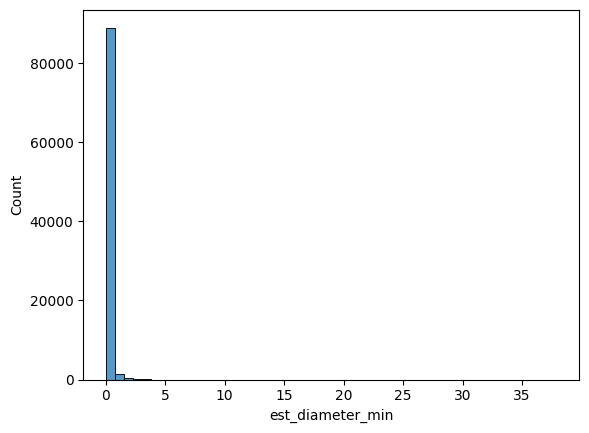

In [13]:
sns.histplot(df['est_diameter_min'] , bins=50)

<Axes: xlabel='relative_velocity', ylabel='Count'>

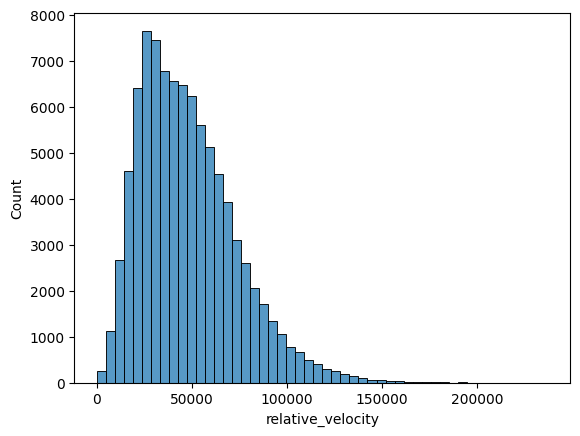

In [14]:
sns.histplot(df['relative_velocity'] , bins=50)

<Axes: xlabel='miss_distance', ylabel='Count'>

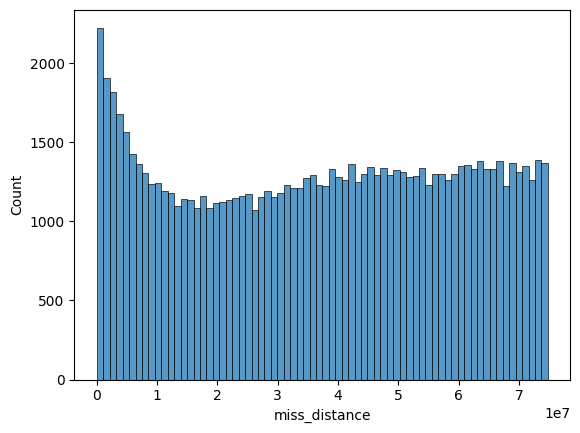

In [15]:
sns.histplot(df['miss_distance'] , bins=70)

<Axes: xlabel='absolute_magnitude', ylabel='Count'>

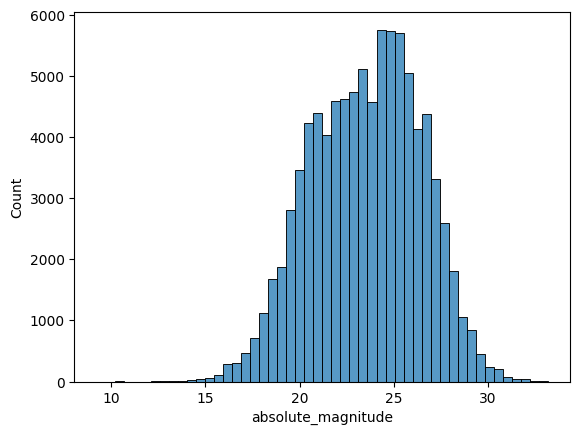

In [16]:
sns.histplot(df['absolute_magnitude'] , bins=50)

## Observations:
* The numerical features have different types of distributions.
* absolute_magnitude has a bell shaped distribution, with most values in the middle.
* miss_distance has a very wide range of values, with more values concentrated toward the lower side.
* est_diameter_min, est_diameter_max, and relative_velocity have right skewed distributions, meaning most values are smaller and fewer values are larger.

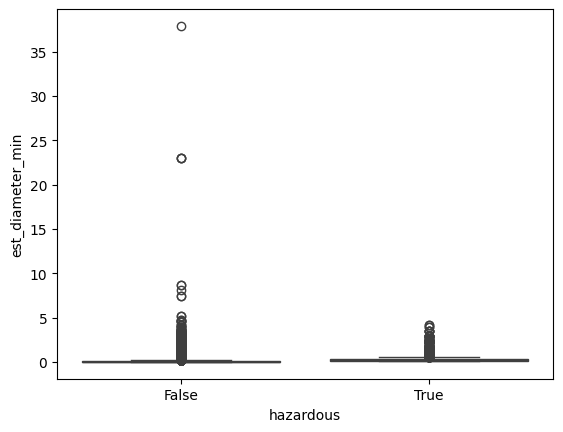

In [17]:
sns.boxplot(x='hazardous', y='est_diameter_min', data=df)
plt.show()

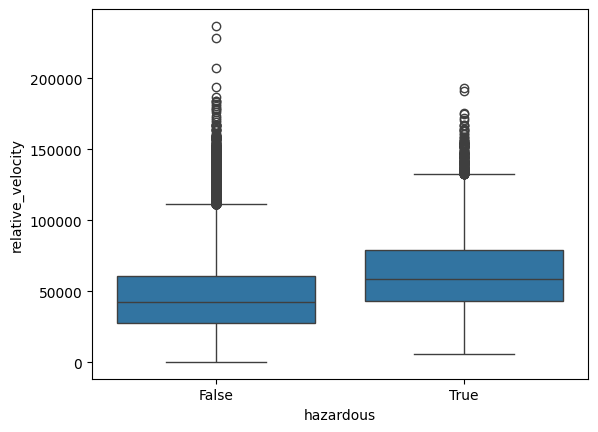

In [18]:
sns.boxplot(x='hazardous', y='relative_velocity', data=df)
plt.show()

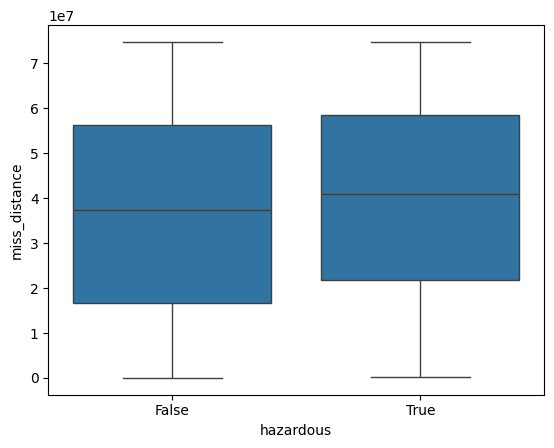

In [19]:
sns.boxplot(x='hazardous', y='miss_distance', data=df)
plt.show()

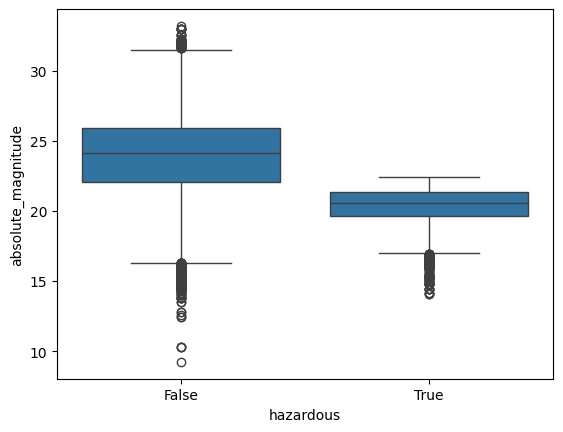

In [20]:
sns.boxplot(x='hazardous', y='absolute_magnitude', data=df)
plt.show()

## Observations:
* relative_velocity and absolute_magnitude show the biggest differences between the two classes.
* miss_distance shows a similar distribution for both classes.
* relative_velocity and absolute_magnitude may be useful for predicting hazardous.
* miss_distance overlaps heavily between the two classes.
* Outliers are present, especially in relative_velocity and est_diameter_min, but the overall class differences are still visible.
* relative_velocity and absolute_magnitude appear to have the strongest relationship with the hazardous target.

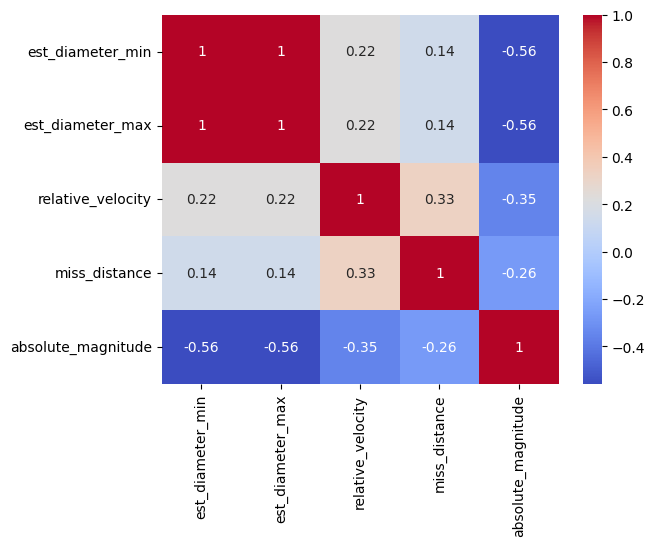

In [21]:
num_cols = ['est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude']

corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

## Observations:
* est_diameter_min and est_diameter_max have a perfect positive correlation (1.00).
* relative_velocity and miss_distance have a weak positive correlation (0.33).
* est_diameter_min/max and absolute_magnitude have a moderate negative correlation (-0.56).
* relative_velocity and absolute_magnitude have a weak-to-moderate negative correlation (-0.35).
* miss_distance and absolute_magnitude have a weak negative correlation (-0.26).
* est_diameter_min/max have very weak positive correlations with relative_velocity (0.22) and miss_distance (0.14).
* The strongest relationship is between est_diameter_min and est_diameter_max. 

## Complete EDA Obs:
* `relative_velocity`, `est_diameter_min`, and `est_diameter_max` are right skewed, while `absolute_magnitude` is more concentrated and `miss_distance` has a wide spread.

* Significant outliers are present in `absolute_magnitude`, `relative_velocity`, `est_diameter_min`, and `est_diameter_max`.

* `absolute_magnitude` and `relative_velocity` show noticeable differences between hazardous and non hazardous asteroids.

* `est_diameter_min` and `est_diameter_max` have a perfect positive correlation of 1.00, while most other features show weak to moderate correlations.

* Since the two diameter features are perfectly correlated, one can be removed to reduce redundancy.

* The target is imbalanced with 81,996 non hazardous and 8,840 hazardous asteroids, so accuracy alone is not sufficient.

* Scaling and suitable transformations may be applied to handle differences in feature ranges and skewness.


In [22]:
X = df.drop(columns=['hazardous', 'est_diameter_max'])
y = df['hazardous']

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score

In [24]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,
                                                 random_state=42,stratify=y)

In [25]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(72668, 4)
(18168, 4)
(72668,)
(18168,)


In [26]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 72668 entries, 2639 to 14305
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   est_diameter_min    72668 non-null  float64
 1   relative_velocity   72668 non-null  float64
 2   miss_distance       72668 non-null  float64
 3   absolute_magnitude  72668 non-null  float64
dtypes: float64(4)
memory usage: 2.8 MB


In [27]:
sc = StandardScaler()
X_train_trans = sc.fit_transform(X_train)
X_test_trans = sc.transform(X_test)

In [28]:
# We used StandardScaler to bring numerical features to a common scale because they have different ranges.
# This helps the classification model learn better.

In [29]:
X_train_trans = pd.DataFrame(X_train_trans, columns=X_train.columns, index=X_train.index)
X_test_trans = pd.DataFrame(X_test_trans, columns=X_test.columns, index=X_test.index)

In [30]:
X_train_trans.head()

,est_diameter_min,relative_velocity,miss_distance,absolute_magnitude
2639,-0.331616,-0.188160,0.494297,0.577785
29138,-0.312486,-1.040729,0.866716,0.412170
36927,0.234246,2.427134,1.219399,-1.009355
61855,0.101960,1.205148,0.843963,-0.836840
15916,-0.386643,-1.147355,0.056145,1.509367


In [31]:
y_train.value_counts()

hazardous
False    65596
True      7072
Name: count, dtype: int64

In [32]:
y_test.value_counts()

hazardous
False    16400
True      1768
Name: count, dtype: int64

## Observation: 
* The target variable is imbalanced, with approximately 90% non hazardous and 10% hazardous asteroids in both the training and testing sets.
* so class weighting will be used during model training to give greater importance to the minority hazardous class.

### Logistic Regression:
* Logistic Regression is a good baseline classification model because it predicts the probability of an asteroid being hazardous or non hazardous.
* It is also simple and interpretable, so we can use its performance as a benchmark to compare with more complex models later.

In [33]:
lr_model = LogisticRegression(class_weight='balanced', random_state=42)
# class_weight='balanced' tells Logistic Regression to give more importance to the minority hazardous class.

In [34]:
lr_model.fit(X_train_trans, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default

In [35]:
y_pred = lr_model.predict(X_test_trans)

In [36]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.7859423161602818
Precision: 0.30422743215802106
Recall: 0.9321266968325792
F1 Score: 0.45873347251217816


## Observaion:
Logistic Regression achieved high recall (93.21%) but low precision (30.42%), indicating that it detects most hazardous asteroids
but also produces many false positives.

## Decision Tree

In [37]:
dt_model = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

In [38]:
dt_model.fit(X_train_trans, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are 

In [39]:
y_pred_dt = dt_model.predict(X_test_trans)

In [40]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

Accuracy: 0.8949801849405549
Precision: 0.4593967517401392
Recall: 0.4479638009049774
F1 Score: 0.4536082474226804


## Observation:
Decision Tree achieved higher accuracy and precision than Logistic Regression, but its recall dropped significantly, resulting in a similar F1 score.

## Random Forest Classifier

In [41]:
rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

In [42]:
rf_model.fit(X_train_trans, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [43]:
y_pred_rf = rf_model.predict(X_test_trans)

In [44]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.8956406869220608
Precision: 0.47227036395147315
Recall: 0.6165158371040724
F1 Score: 0.534838076545633


## Observation:
Random Forest achieved the highest accuracy (89.56%), precision (47.23%), and F1 score (53.48%) among the three models tested so far, with a recall of 61.65%.

## SVM

In [45]:
svm_model = SVC(class_weight='balanced', random_state=42)
svm_model.fit(X_train_trans, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200


In [46]:
y_pred_svm = svm_model.predict(X_test_trans)

In [47]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))

Accuracy: 0.7687142228093351
Precision: 0.2954621848739496
Recall: 0.994343891402715
F1 Score: 0.45555843482767555


## Observation:
* SVM achieved the highest recall (99.43%), detecting almost all hazardous asteroids, but had low precision (29.55%) and accuracy (76.87%).
* SVM is extremely good at catching hazardous asteroids, but it is flagging many non hazardous asteroids as hazardous.

## KNN

In [48]:
knn_model = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_model.fit(X_train_trans, y_train)

,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[bool](2,)","[False, True]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [49]:
y_pred_knn = knn_model.predict(X_test_trans)

In [50]:
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))

Accuracy: 0.9004293262879789
Precision: 0.48412083656080557
Recall: 0.35350678733031676
F1 Score: 0.40863027133050017


## Observation:
KNN achieved the highest accuracy (90.04%) among the tested models, but its low recall (35.35%) means it misses many hazardous asteroids, resulting in the lowest F1 score (40.86%).

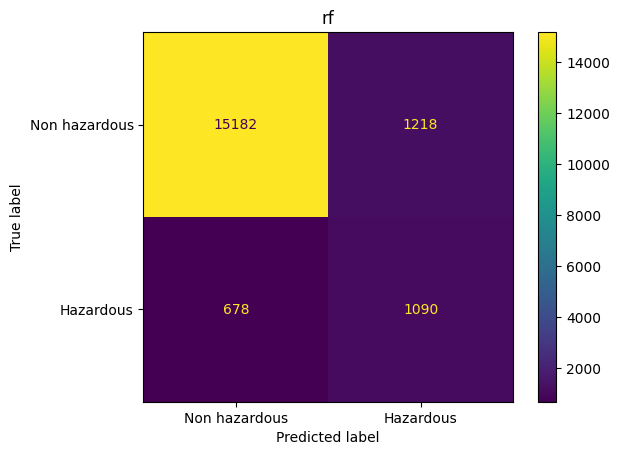

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non hazardous', 'Hazardous']
)

disp.plot()
plt.title('rf')
plt.show()

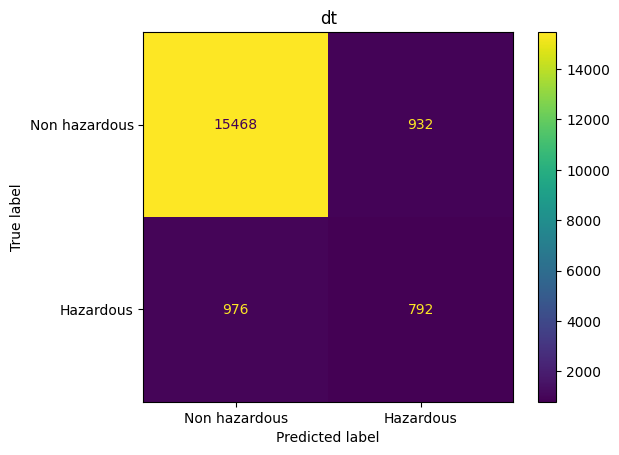

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non hazardous', 'Hazardous']
)

disp.plot()
plt.title('dt')
plt.show()

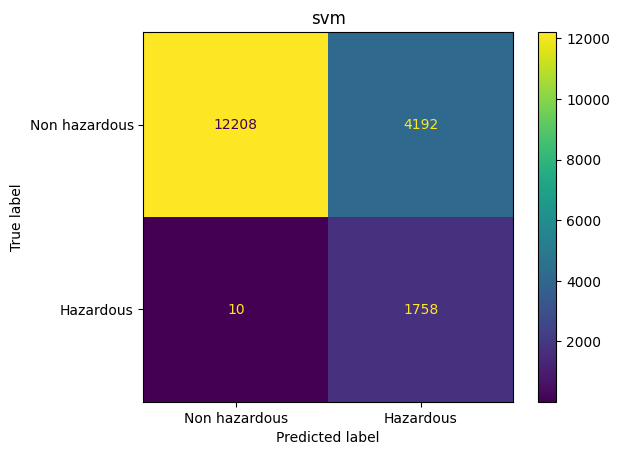

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non hazardous', 'Hazardous']
)

disp.plot()
plt.title('svm')
plt.show()

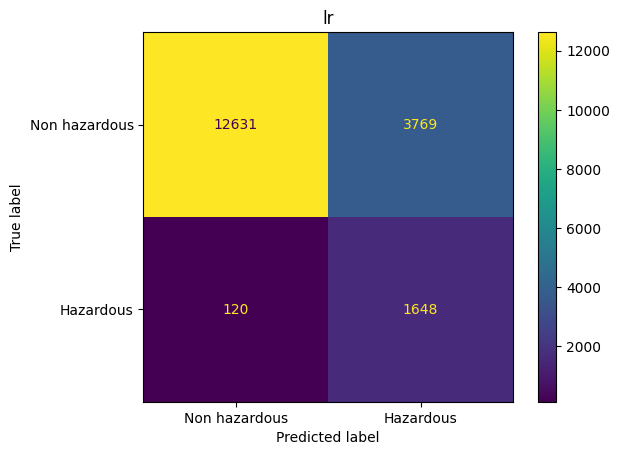

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non hazardous', 'Hazardous']
)

disp.plot()
plt.title('lr')
plt.show()

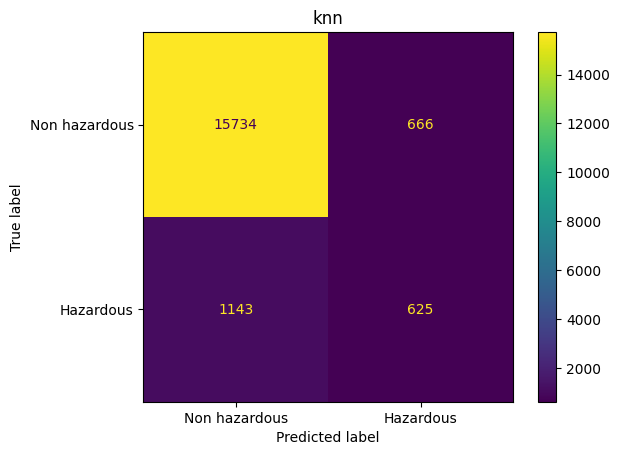

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non hazardous', 'Hazardous']
)

disp.plot()
plt.title('knn')
plt.show()

## Observations
* Logistic Regression: Correctly identifies most hazardous asteroids, but produces a considerable number of false positives.
* Decision Tree: Correctly identifies non hazardous asteroids well, but misses a significant number of hazardous asteroids.
* Random Forest: Detects more hazardous asteroids than Decision Tree and provides a better balance between correct and incorrect predictions.
* SVM: Detects almost all hazardous asteroids and has the fewest false negatives, but produces many false positives.
* KNN: Correctly identifies most non hazardous asteroids but misses many hazardous asteroids.

In [56]:
y_score_svm = svm_model.decision_function(X_test_trans)
y_score_lr = lr_model.predict_proba(X_test_trans)[:, 1]
y_score_dt = dt_model.predict_proba(X_test_trans)[:, 1]
y_score_rf = rf_model.predict_proba(X_test_trans)[:, 1]
y_score_knn = knn_model.predict_proba(X_test_trans)[:, 1]

In [57]:
print("SVM ROC AUC:",roc_auc_score(y_test, y_score_svm))
print("Logistic Regression:", roc_auc_score(y_test, y_score_lr))
print("Decision Tree:", roc_auc_score(y_test, y_score_dt))
print("Random Forest:", roc_auc_score(y_test, y_score_rf))
print("SVM:", roc_auc_score(y_test, y_score_svm))
print("KNN:", roc_auc_score(y_test, y_score_knn))

SVM ROC AUC: 0.8972821708420704
Logistic Regression: 0.8794440114225802
Decision Tree: 0.6955672663061472
Random Forest: 0.9304438838152522
SVM: 0.8972821708420704
KNN: 0.8540301153294338


## Observations:
* Random Forest performed the best overall, achieving the highest ROC AUC of 0.9304 and showing the strongest ability to distinguish between hazardous and non hazardous asteroids.
* Random Forest's confusion matrix also showed strong classification performance, with a high number of correctly classified samples and relatively fewer false predictions compared with the other models.

### Hyperparameter Tuning

In [58]:
from sklearn.model_selection import GridSearchCV

In [59]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}

In [60]:
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

In [61]:
rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls th

In [62]:
print(rf_grid.best_params_)

{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


In [63]:
print(rf_grid.best_score_)

0.9299034128127414


## Observations:
* So tuning did not improve the ROC AUC. It decreased very slightly by about 0.0005,
* Hyperparameter tuning produced a Random Forest with 200 trees and a minimum split size of 5. The tuned model achieved a ROC AUC of 0.9299, which was very close to the original model's 0.9304.

In [64]:
# train the model
from sklearn.ensemble import RandomForestClassifier

final_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

final_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [65]:
# 0.5 threshold (y_pred)

In [66]:
y_pred = final_rf.predict(X_test)
y_pred_proba = final_rf.predict_proba(X_test)[:, 1]

In [67]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))

Accuracy: 0.9163364156759137
Precision: 0.6174242424242424
Recall: 0.36877828054298645
F1 Score: 0.46175637393767704
ROC AUC: 0.9331198267299414


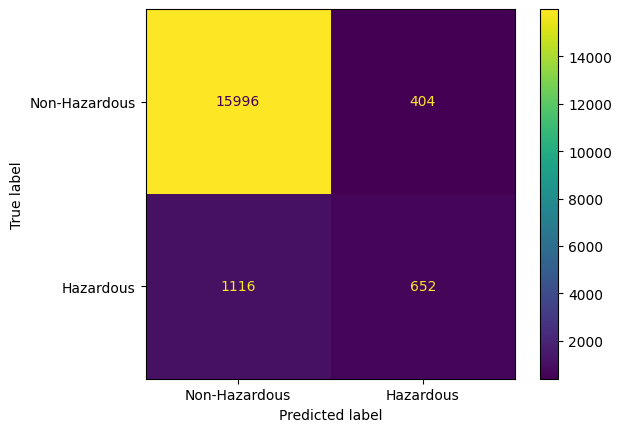

In [68]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Hazardous", "Hazardous"]
)

disp.plot()
plt.show()

## Observations:
* Accuracy is 91.63%, meaning the model correctly classified most of the test samples.
* ROC AUC is 0.9331, which is the strongest result we've seen so far. This indicates that the Random Forest has a very good ability to distinguish hazardous from non hazardous asteroids.
* Precision is 61.74%, meaning that when the model predicts an asteroid as hazardous, around 62% of those predictions are actually hazardous.
* Recall is 36.88%, which is relatively low. This means the model is missing a significant number of actual hazardous asteroids.
* F1 score is 46.18%, showing that there is a tradeoff between precision and recall that we may need to consider carefully. 

In [69]:
# 0.10 threshold

In [70]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.6, 0.05)

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    
    print(
        "Threshold:", round(threshold, 2),
        "Precision:", round(precision_score(y_test, y_pred_threshold), 3),
        "Recall:", round(recall_score(y_test, y_pred_threshold), 3),
        "F1:", round(f1_score(y_test, y_pred_threshold), 3)
    )

Threshold: 0.1 Precision: 0.344 Recall: 0.947 F1: 0.505
Threshold: 0.15 Precision: 0.374 Recall: 0.891 F1: 0.526
Threshold: 0.2 Precision: 0.404 Recall: 0.822 F1: 0.542
Threshold: 0.25 Precision: 0.438 Recall: 0.749 F1: 0.553
Threshold: 0.3 Precision: 0.468 Recall: 0.659 F1: 0.547
Threshold: 0.35 Precision: 0.5 Recall: 0.572 F1: 0.534
Threshold: 0.4 Precision: 0.533 Recall: 0.494 F1: 0.513
Threshold: 0.45 Precision: 0.576 Recall: 0.435 F1: 0.495
Threshold: 0.5 Precision: 0.617 Recall: 0.369 F1: 0.462
Threshold: 0.55 Precision: 0.67 Recall: 0.314 F1: 0.428


In [71]:
# 0.25 threshold 

In [72]:
y_pred_final = (y_pred_proba >= 0.25).astype(int)

print("Precision:", precision_score(y_test, y_pred_final))
print("Recall:", recall_score(y_test, y_pred_final))
print("F1 Score:", f1_score(y_test, y_pred_final))
print("Final Accuracy:", accuracy_score(y_test, y_pred_final))

Precision: 0.4381204500330907
Recall: 0.748868778280543
F1 Score: 0.5528183716075157
Final Accuracy: 0.8821003963011889


## Observation:
The classification threshold was reduced from 0.50 to 0.25 to prioritize the detection of hazardous asteroids. This increased recall from 36.88% to 74.89% and improved the F1 score from 46.18% to 55.28%. Although precision decreased to 43.81%, the lower threshold allows the model to identify a much larger proportion of actual hazardous asteroids.

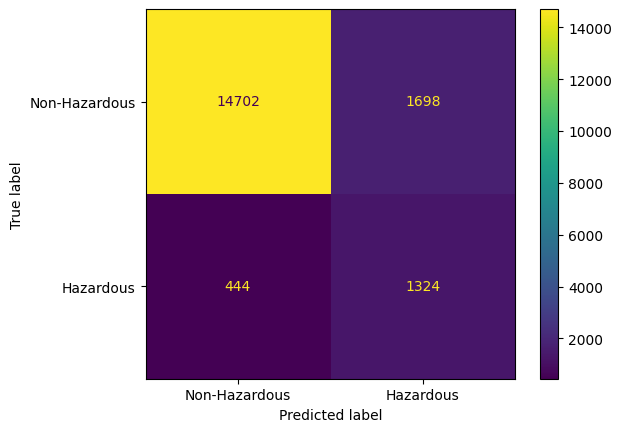

In [73]:
cm = confusion_matrix(y_test, y_pred_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Hazardous", "Hazardous"]
)

disp.plot()
plt.show()

## Observations:
* Random Forest achieved a ROC AUC of 93.31%, indicating strong ability to distinguish hazardous and non hazardous asteroids.
* The threshold was reduced from 0.50 to 0.25 to prioritize detecting hazardous asteroids.
* This increased recall from 36.88% to 74.89%, meaning the model identifies a much larger proportion of actual hazardous asteroids.
* The final model correctly identified 1,324 hazardous asteroids, while 444 hazardous asteroids were missed.
* 1,698 non hazardous asteroids were incorrectly classified as hazardous, resulting in lower precision of 43.81%.
* The final accuracy is 88.21%. It is lower than the 91.63% obtained at threshold 0.50 because lowering the threshold creates more positive predictions.
* The F1 score improved from 46.18% to 55.28%, giving a better balance between precision and recall.